# Notebook 4# EDA and visualization (by Amin Sharifi - asharifi@berkeley.edu)


In this section, we will visualize the key features of our dataset to understand historical match patterns, scoring distributions, and variable relationships before feeding this data into our machine learning models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set general visualization style
sns.set_theme(style="whitegrid")

#Load the necessary datasets using the correct relative path
results = pd.read_csv("../data/results.csv")
eloratings = pd.read_csv("../data/eloratings.csv")

#Base Preprocessing
#Drop future matches that do not have scores yet
results = results.dropna(subset=["home_score", "away_score"]).copy()

#Feature Engineering for EDA
results['date'] = pd.to_datetime(results['date'])
results['year'] = results['date'].dt.year
results['total_goals'] = results['home_score'] + results['away_score']
results['goal_diff'] = (results['home_score'] - results['away_score']).abs()

eloratings['date'] = pd.to_datetime(eloratings['date'], errors='coerce')

### 1. Distribution of Match Goals

Understanding the frequency of goals is critical since match outcomes (Win/Draw/Loss) are directly derived from goals scored. The histogram below visualizes the distribution of total goals per match.

**Interpretation:** The distribution is highly right-skewed. The vast majority of historical matches end with between 1 and 3 total goals, which is characteristic of a low-scoring sport like football. The long tail represents rare high-scoring outliers (which we previously identified in our data cleaning step). This skewness suggests that when predicting exact scores (e.g., using Poisson regression), models should account for a heavy concentration around low integer values.

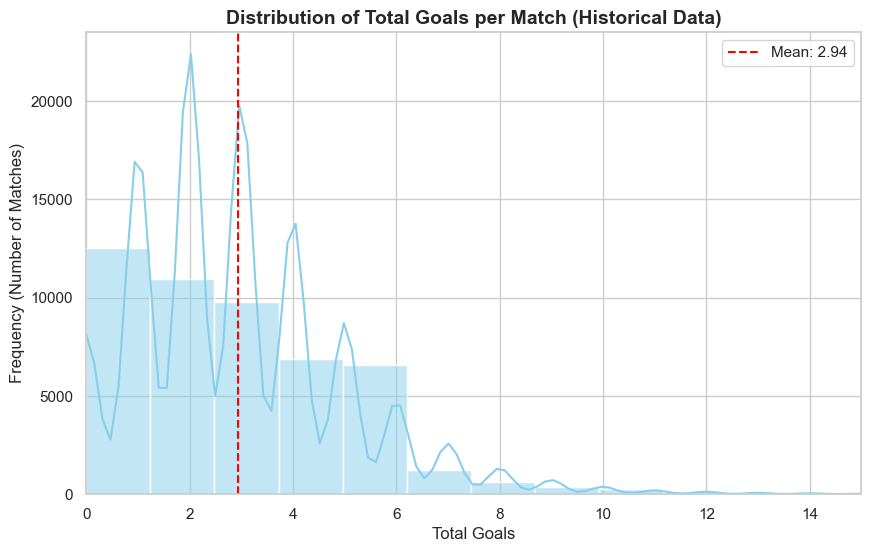

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=results, x='total_goals', bins=25, kde=True, color='skyblue')
plt.title('Distribution of Total Goals per Match (Historical Data)', fontsize=14, fontweight='bold')
plt.xlabel('Total Goals', fontsize=12)
plt.ylabel('Frequency (Number of Matches)', fontsize=12)
plt.xlim(0, 15) # Focusing on the main distribution
plt.axvline(results['total_goals'].mean(), color='red', linestyle='--', label=f"Mean: {results['total_goals'].mean():.2f}")
plt.legend()
plt.show()

### 2. Home Advantage Analysis

Home-field advantage is a well-known phenomenon in sports. To quantify this, we use a box plot to compare the distribution of goals scored by home teams versus away teams in non-neutral venues.

**Interpretation:** The box plot shows that the median and upper quartile for goals scored by the home team are consistently higher than those for the away team. The density of outliers (points above the whiskers) is also heavier for the home team. This confirms that 'Home Advantage' is a significant pattern in our dataset. For our 2026 World Cup predictions, recognizing whether a team is the host nation (or playing on a familiar continent) will be a valuable feature to include in the baseline and improved models.

C:\Users\shari\AppData\Local\Temp\ipykernel_5852\1036848796.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='venue', y='goals', data=scores_melted, palette='Set2')


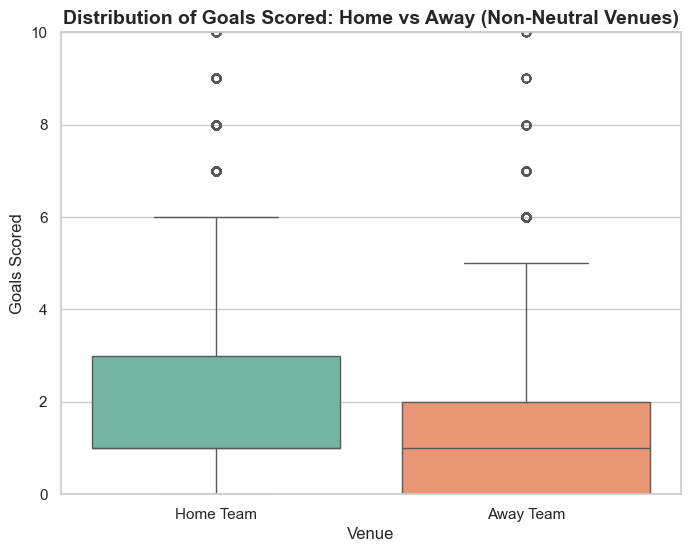

In [7]:
#Filter out matches played at neutral venues to accurately assess home advantage
non_neutral_matches = results[results['neutral'] == False].copy()

#Melt the dataframe to have a single column for goals and a categorical column for venue (Home/Away)
scores_melted = pd.melt(non_neutral_matches, id_vars=['date', 'tournament'], 
                        value_vars=['home_score', 'away_score'], 
                        var_name='venue', value_name='goals')

plt.figure(figsize=(8, 6))
sns.boxplot(x='venue', y='goals', data=scores_melted, palette='Set2')
plt.title('Distribution of Goals Scored: Home vs Away (Non-Neutral Venues)', fontsize=14, fontweight='bold')
plt.xlabel('Venue', fontsize=12)
plt.ylabel('Goals Scored', fontsize=12)
plt.ylim(0, 10) #Limiting y-axis to see the core boxplot distribution clearly
plt.xticks([0, 1], ['Home Team', 'Away Team'])
plt.show()

### 3. Competitiveness Over Time

To see if the gap between teams is narrowing or widening, we can look at the average goal difference per match over the decades. 

**Interpretation:** The line plot reveals a steady downward trend in the average goal difference over the last century. In the late 1800s and early 1900s, match scores were highly erratic, and blowouts were common. As international football professionalized and tactical discipline improved globally, matches became significantly more competitive. This trend suggests that weighting recent match history more heavily than older history will be crucial for training a model that accurately reflects the tighter margins of modern World Cup matches.

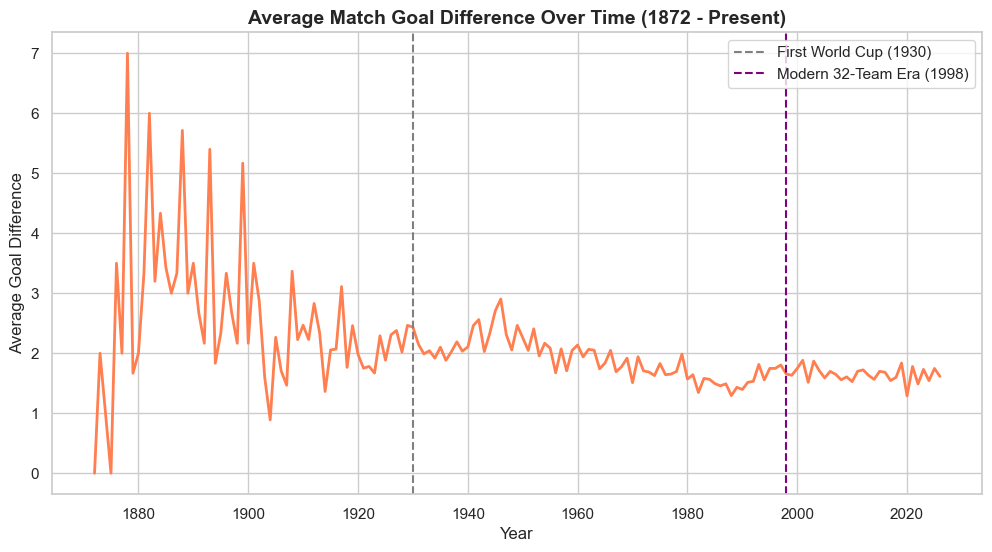

In [9]:
#Calculate average goal difference by year
yearly_stats = results.groupby('year')['goal_diff'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='goal_diff', color='coral', linewidth=2)
plt.title('Average Match Goal Difference Over Time (1872 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Goal Difference', fontsize=12)
plt.axvline(x=1930, color='grey', linestyle='--', label='First World Cup (1930)')
plt.axvline(x=1998, color='purple', linestyle='--', label='Modern 32-Team Era (1998)')
plt.legend()
plt.show()

### 4. Correlation Analysis

A correlation heatmap helps us identify how numerical features move in relation to one another, preventing issues like multicollinearity in our predictive models.

**Interpretation:** * `total_goals` has a very strong positive correlation with `home_score` (0.83) and a slightly weaker one with `away_score` (0.68), indicating that high-scoring matches are historically driven more by home team scoring.
* There is virtually no correlation between `home_score` and `away_score` (-0.14), meaning knowing one team's score provides very little linear predictive power regarding the opponent's score. 
* `goal_diff` has a positive correlation with `home_score` (0.59) and a negative one with `away_score` (-0.23), reaffirming that larger score disparities typically lean in favor of the home team.

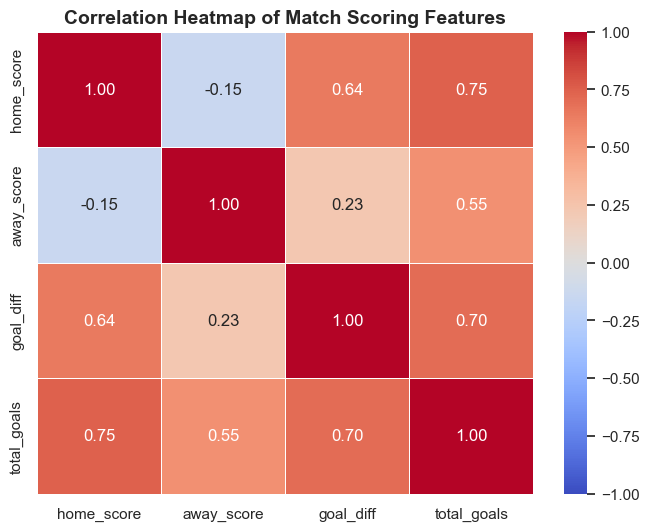

In [11]:
numeric_cols = ['home_score', 'away_score', 'goal_diff', 'total_goals']
corr_matrix = results[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Match Scoring Features', fontsize=14, fontweight='bold')
plt.show()

### 5. Distribution of Team Strength (Elo Ratings)

Because Elo ratings will be our primary feature for capturing "team strength," it's vital to check its distribution.

**Interpretation:** The Elo ratings follow a near-normal distribution centered roughly around 1500–1600. The symmetry and lack of extreme skewness make it an ideal numerical feature for models like Logistic Regression, XGBoost, or Random Forests. The long right tail indicates the elite "powerhouse" nations (ratings > 2000) that typically reach the deep knockout stages of the World Cup.

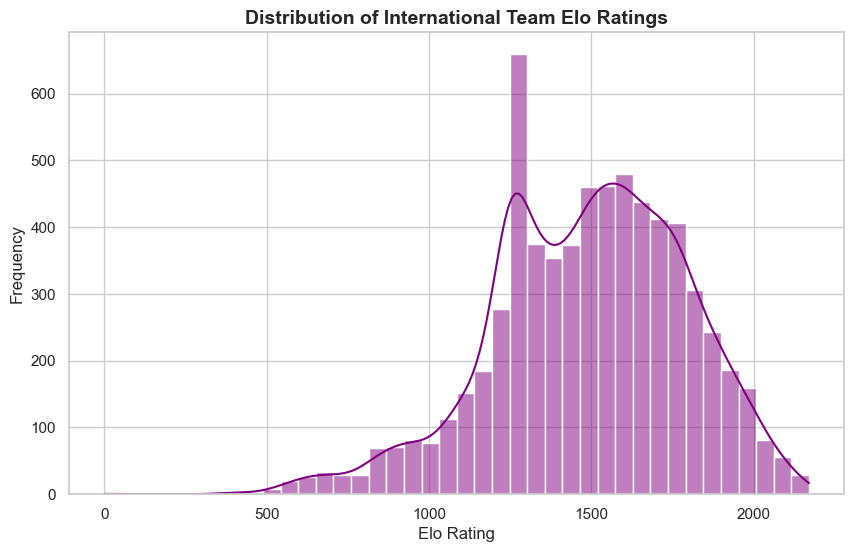

In [13]:
#Drop missing ratings for visualization purposes
elo_clean = eloratings.dropna(subset=['rating'])

plt.figure(figsize=(10, 6))
sns.histplot(data=elo_clean, x='rating', bins=40, kde=True, color='purple')
plt.title('Distribution of International Team Elo Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Elo Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()